### 1. Problem Statement:

The objective is to implement an integrated machine learning framework combining traditional classifiers such as K-Nearest Neighbors (KNN) and Support Vector Machines (SVM) with Convolutional Neural Networks (CNN) to classify morphological changes in cytology images for cervical cancer diagnosis. The integration of CNNs with these machine learning models aims to extract robust feature representations and enhance classification performance. This approach can assist pathologists in achieving more precise and reliable medical diagnostics, reducing errors caused by fatigue and variability in expertise. Efficiently detecting subtle changes in cytology images can streamline cervical cancer screening, improve diagnostic accuracy, and contribute to better healthcare outcomes.

### 2.Data Source:

The **SIPaKMeD** dataset is a significant resource for the classification of cervical cells in Pap smear images, consisting of **4049** annotated cell images extracted from 966 clusters captured using a CCD camera attached to an optical microscope. Expert cytopathologists have categorized these images into five distinct classes based on their cytomorphological features: superficial-intermediate, parabasal, koilocytotic, dyskeratotic, and metaplastic cells. This meticulous classification enhances the dataset's usability for research and supports the development of robust machine learning models aimed at cervical cancer diagnosis.

* The link of dataset: https://www.kaggle.com/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed

### 3.Imports and Library Loading

In [ ]:
# Importing the os module for interacting with the operating system (e.g., file and directory management)
import os
# Importing OpenCV library for image processing
import cv2
# Importing pandas for data manipulation and analysis
import pandas as pd
# Importing numpy for numerical operations on arrays
import numpy as np
# Importing Matplotlib for plotting graphs and visualizations
import matplotlib.pyplot as plt
# Importing seaborn for advanced data visualization and statistical plotting
import seaborn as sns
# Importing PIL (Python Imaging Library) for image file processing
from PIL import Image
# Importing train_test_split for splitting data into training and testing sets
from sklearn.model_selection import train_test_split
# Importing PCA (Principal Component Analysis) for dimensionality reduction
from sklearn.decomposition import PCA
# Importing SVC (Support Vector Classifier) for classification tasks
from sklearn.svm import SVC
# Importing LabelEncoder to encode labels into numerical format
from sklearn.preprocessing import LabelEncoder
# Importing metrics for evaluating model performance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss
# Importing Sequential class from TensorFlow Keras to define a deep learning model
from tensorflow.keras.models import Sequential
# Importing layers from Keras for building Convolutional Neural Networks (CNNs)
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense, Dropout
# Importing ImageDataGenerator for augmenting image data during training
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
# Importing utilities to load, preprocess, and convert images for input into a Keras model
from tensorflow.keras.preprocessing import image

In [ ]:
# Define directories and categories
base_dir = "/Users/altalhishahd/Desktop/DS Master Files/Semester 3/Machine Learning/project/archive"
categories = ["im_Dyskeratotic", "im_Koilocytotic", "im_Metaplastic", 
              "im_Parabasal", "im_Superficial-Intermediate"]

### 4.Exploratory Data Analysis (EDA)

In [3]:
# Count images in each category
image_counts = {}
for category in categories:
    category_path = os.path.join(base_dir, category, category, "CROPPED")  
    image_counts[category] = len([f for f in os.listdir(category_path) if f.endswith(('.bmp', '.jpg', '.png'))])

In [4]:
# Count images in each category
image_counts = {}
for category in categories:
    category_path = os.path.join(base_dir, category, category, "CROPPED")  
    image_counts[category] = len([f for f in os.listdir(category_path) if f.endswith(('.bmp', '.jpg', '.png'))])
print(image_counts)

{'im_Dyskeratotic': 813, 'im_Koilocytotic': 825, 'im_Metaplastic': 793, 'im_Parabasal': 787, 'im_Superficial-Intermediate': 831}


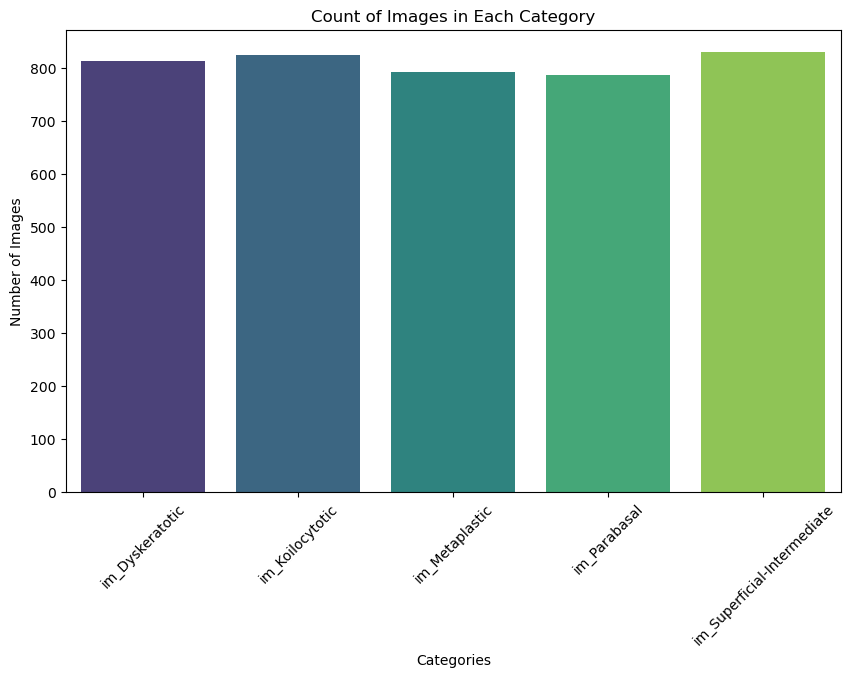

In [5]:
# Plot image counts
plt.figure(figsize=(10, 6))
sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()), hue=list(image_counts.keys()), palette='viridis', legend=False)  
plt.title('Count of Images in Each Category')
plt.xlabel('Categories')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

This bar chart shows the distribution of images across five categories: **Dyskeratotic**, **Koilocytotic**, **Metaplastic**, **Parabasal**, and **Superficial-Intermediate**. Each bar represents the number of images available in the dataset for that category, and the heights of the bars indicate that the dataset is relatively balanced, with each category containing approximately 800 images. This balance is critical for training machine learning models, as it ensures that the models are not biased toward any particular category, leading to better generalization during classification tasks.

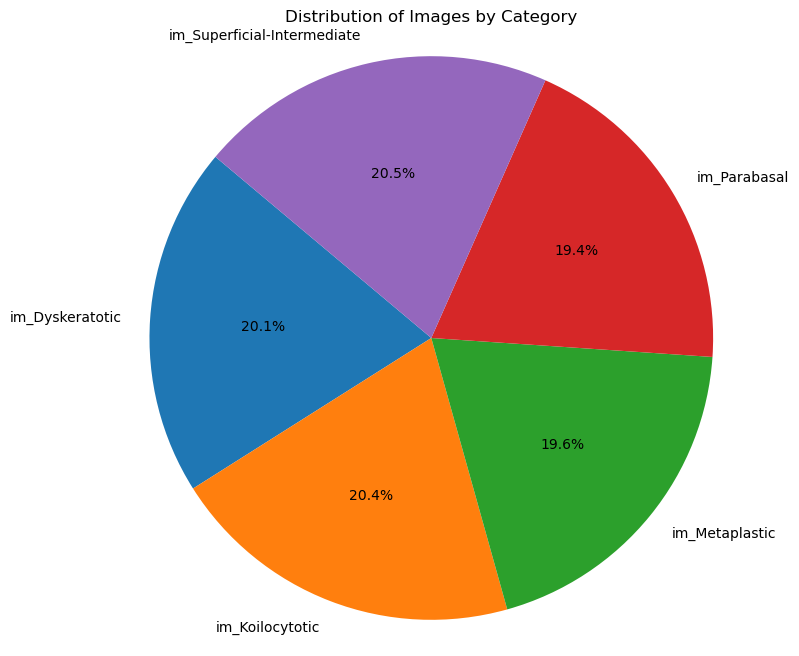

In [6]:
#pie chart
plt.figure(figsize=(8, 8))
plt.pie(image_counts.values(), labels=image_counts.keys(), autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Images by Category')
plt.axis('equal') 
plt.show()

This pie chart illustrates the **percentage distribution of images across five categories**: **Dyskeratotic**, **Koilocytotic**, **Metaplastic**, **Parabasal**, and **Superficial-Intermediate**. Each segment represents the proportion of images within a specific category relative to the total dataset. The chart shows a fairly balanced distribution, with each category contributing approximately 19% to 21% of the dataset. Such a balanced dataset is ideal for training machine learning models, as it helps to minimize bias and ensures that the model is equally exposed to all categories during training.

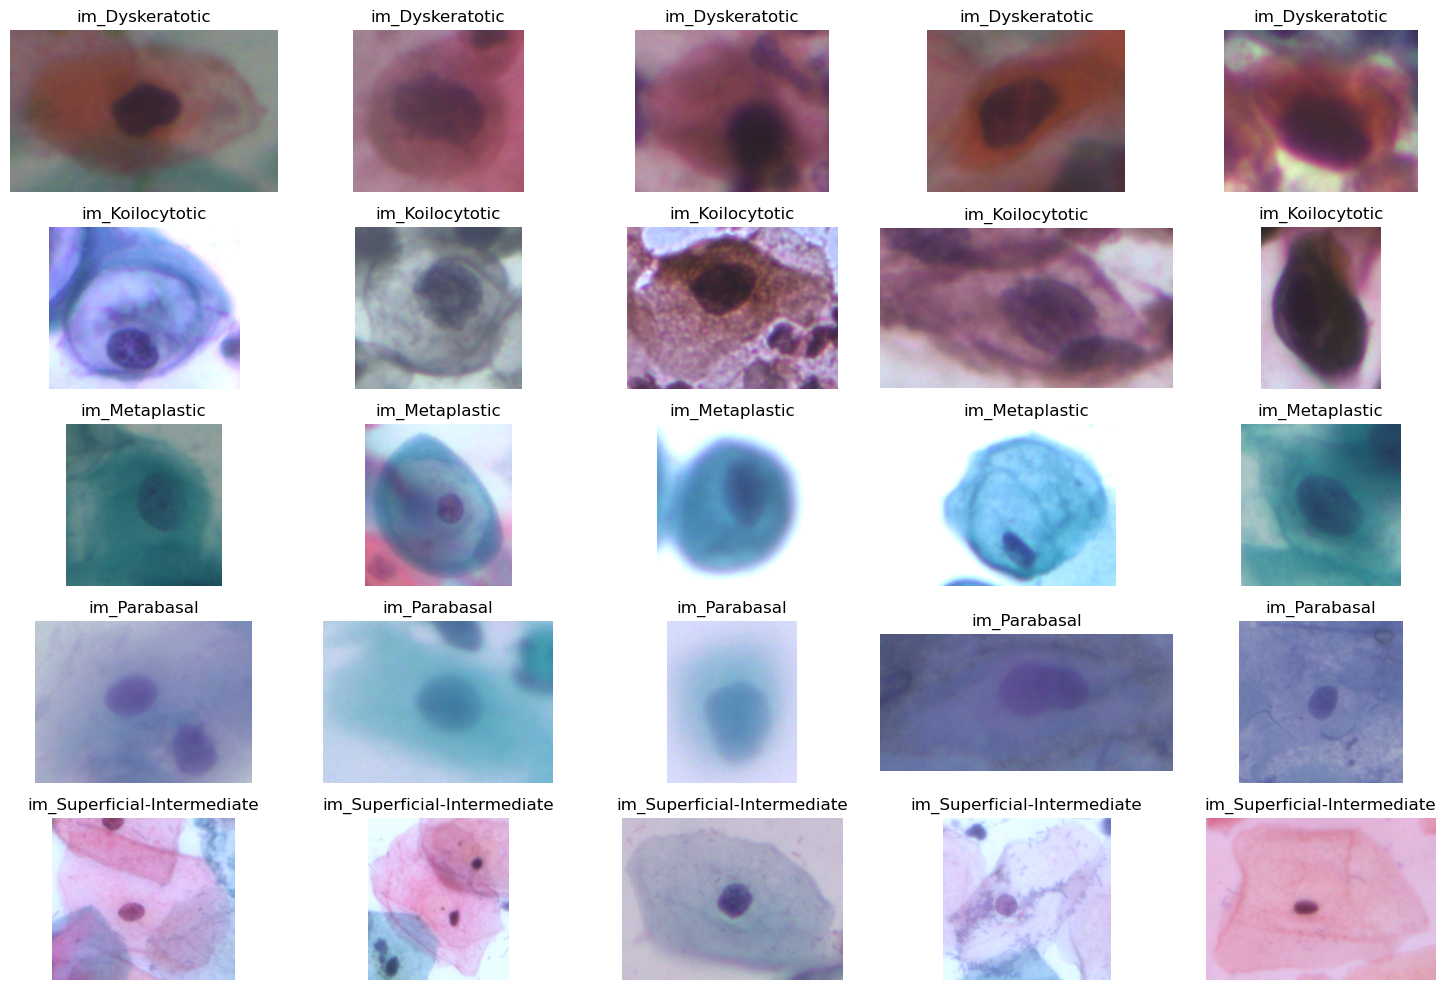

In [7]:
# Display images from each category
def display_images_from_folders(base_dir, categories, num_images=5):
    plt.figure(figsize=(15, 10))
    
    for i, category in enumerate(categories):
        category_path = os.path.join(base_dir, category, category, "CROPPED")
        image_files = [f for f in os.listdir(category_path) if f.endswith(('.bmp', '.jpg', '.png'))]
        
        for j, image_file in enumerate(image_files[:num_images]):
            img_path = os.path.join(category_path, image_file)
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
            
            plt.subplot(len(categories), num_images, i * num_images + j + 1)
            plt.imshow(image)
            plt.axis('off')  
            plt.title(f"{category}") 

    plt.tight_layout()
    plt.show()

display_images_from_folders(base_dir, categories, num_images=5)

### 5.Pre-processing

In [8]:
# Define Normal and Abnormal categories
normal_categories = ["im_Superficial-Intermediate", "im_Parabasal"]
abnormal_categories = ["im_Koilocytotic", "im_Dyskeratotic", "im_Metaplastic"]

# Create a DataFrame with image paths and labels
def create_image_paths_dataframe(base_dir, categories, normal_categories, abnormal_categories):
    data = []
    for category in categories:
        category_path = os.path.join(base_dir, category, category, "CROPPED")
        image_files = [f for f in os.listdir(category_path) if f.endswith(('.bmp', '.jpg', '.png'))]
        label = "normal" if category in normal_categories else "abnormal"
        for image_file in image_files:
            img_path = os.path.join(category_path, image_file)
            data.append({'image_path': img_path, 'label': label})
    return pd.DataFrame(data)

df_image_paths = create_image_paths_dataframe(base_dir, categories, normal_categories, abnormal_categories)
print(df_image_paths['label'].value_counts())

label
abnormal    2431
normal      1618
Name: count, dtype: int64


In [9]:
# Load images and labels
def load_images_and_labels(df, target_size=(64, 64)):
    images = []
    labels = []
    for _, row in df.iterrows():
        img = cv2.imread(row['image_path'])
        img = cv2.resize(img, target_size)
        images.append(img)
        labels.append(row['label'])
    return np.array(images), np.array(labels)

images, labels = load_images_and_labels(df_image_paths)
images = images / 255.0  # Normalize pixel values

In [10]:
# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

In [11]:
# Split data into train, validation, and test sets (70% train, 15% validation, 15% test)
X_train, X_val_test, y_train, y_val_test = train_test_split(images, encoded_labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state=42)

In [12]:
# Display image counts
print(f"Found {len(X_train)} images belonging to {len(np.unique(y_train))} classes.")
print(f"Found {len(X_val)} images belonging to {len(np.unique(y_val))} classes.")
print(f"Found {len(X_test)} images belonging to {len(np.unique(y_test))} classes.")

Found 2834 images belonging to 2 classes.
Found 607 images belonging to 2 classes.
Found 608 images belonging to 2 classes.


In [13]:
# Data augmentation
datagen = ImageDataGenerator(rotation_range=30, zoom_range=0.2, horizontal_flip=True)
datagen.fit(X_train)

### 6.Build the model

#### 6.1 CNN as Feature extraction

In [14]:
# Build CNN model
cnn_model = Sequential([
    Input(shape=(64, 64, 3)),  # Explicitly define the input shape
    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')  # Binary classification
])

In [15]:
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [16]:
# Train CNN model
cnn_model.fit(datagen.flow(X_train, y_train, batch_size=32), epochs=10, validation_data=(X_val, y_val))

Epoch 1/10


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5806 - loss: 0.7040 - val_accuracy: 0.8023 - val_loss: 0.4305
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8057 - loss: 0.4609 - val_accuracy: 0.7661 - val_loss: 0.4513
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8270 - loss: 0.3897 - val_accuracy: 0.8336 - val_loss: 0.3527
Epoch 4/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8664 - loss: 0.3260 - val_accuracy: 0.8880 - val_loss: 0.2501
Epoch 5/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8779 - loss: 0.3026 - val_accuracy: 0.8896 - val_loss: 0.2759
Epoch 6/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8875 - loss: 0.2789 - val_accuracy: 0.9028 - val_loss: 0.2362
Epoch 7/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8977 - loss: 0.2658 - val_accuracy: 0.8847 - val_loss: 0.2669
Epoch 8/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8847 - loss: 0.2833 - val_accuracy: 0.8847 - val_loss: 0.

In [17]:
# Feature extraction with CNN
feature_extractor = Sequential(cnn_model.layers[:-1])  # Remove the output layer
feature_extractor.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

train_features = feature_extractor.predict(X_train)
val_features = feature_extractor.predict(X_val)
test_features = feature_extractor.predict(X_test)

89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [18]:
# Apply PCA
pca = PCA(n_components=50)
train_features_pca = pca.fit_transform(train_features)
val_features_pca = pca.transform(val_features)
test_features_pca = pca.transform(test_features)

#### 6.2 SVM as Classifier

In [19]:
# Train SVM on PCA features
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(train_features_pca, y_train)


SVC(kernel='linear')

In [20]:
# Evaluate SVM on validation set
val_predictions = svm_model.predict(val_features_pca)
val_accuracy = accuracy_score(y_val, val_predictions)
# Evaluate SVM on test set
test_predictions = svm_model.predict(test_features_pca)

# Calculate CNN+SVM accuracy
cnn_svm_accuracy = accuracy_score(y_test, test_predictions) * 100

# Print the CNN+SVM Accuracy and Classification Report
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"CNN+SVM Test Accuracy: {cnn_svm_accuracy:.2f}%")
print("Classification Report:")
print(classification_report(y_test, test_predictions, target_names=label_encoder.classes_))

Validation Accuracy: 92.42%
CNN+SVM Test Accuracy: 91.61%
Classification Report:
              precision    recall  f1-score   support

    abnormal       0.96      0.91      0.93       394
      normal       0.85      0.93      0.89       214

    accuracy                           0.92       608
   macro avg       0.90      0.92      0.91       608
weighted avg       0.92      0.92      0.92       608



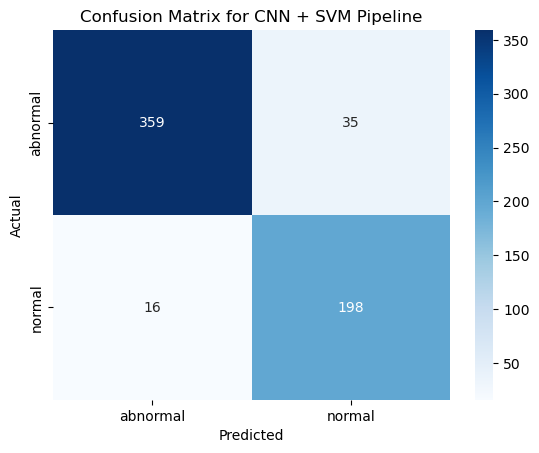

In [21]:
# Confusion Matrix for Test Set
cm = confusion_matrix(y_test, test_predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix for CNN + SVM Pipeline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

This confusion matrix represents the performance of the **CNN + SVM pipeline** in classifying images as either **abnormal** or **normal**. The matrix has the following breakdown:

- **True Positives (359)**: Abnormal cases correctly predicted as abnormal.
- **False Positives (35)**: Normal cases incorrectly predicted as abnormal.
- **True Negatives (198)**: Normal cases correctly predicted as normal.
- **False Negatives (16)**: Abnormal cases incorrectly predicted as normal.

The majority of predictions are correct, as evidenced by the high values along the diagonal (359 and 198). The low off-diagonal values (35 and 16) indicate relatively few misclassifications. This shows that the model has strong performance in both sensitivity (correctly identifying abnormal cases) and specificity (correctly identifying normal cases).

#### 6.3 KNN as Classifier

In [23]:
# Train KNN on PCA features
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors
knn_model.fit(train_features_pca, y_train)

KNeighborsClassifier()

In [25]:
# Evaluate KNN on validation set
val_predictions_knn = knn_model.predict(val_features_pca)
val_accuracy_knn = accuracy_score(y_val, val_predictions_knn)

In [26]:
# Evaluate KNN on test set
test_predictions_knn = knn_model.predict(test_features_pca)

In [27]:
# Calculate CNN+KNN accuracy
cnn_knn_accuracy = accuracy_score(y_test, test_predictions_knn) * 100

In [28]:
# Print the CNN+KNN Accuracy and Classification Report
print(f"CNN+KNN Test Accuracy: {cnn_knn_accuracy:.2f}%")
print("Classification Report for CNN + KNN:")
print(classification_report(y_test, test_predictions_knn, target_names=label_encoder.classes_))

CNN+KNN Test Accuracy: 94.57%
Classification Report for CNN + KNN:
              precision    recall  f1-score   support

    abnormal       0.96      0.95      0.96       394
      normal       0.91      0.93      0.92       214

    accuracy                           0.95       608
   macro avg       0.94      0.94      0.94       608
weighted avg       0.95      0.95      0.95       608



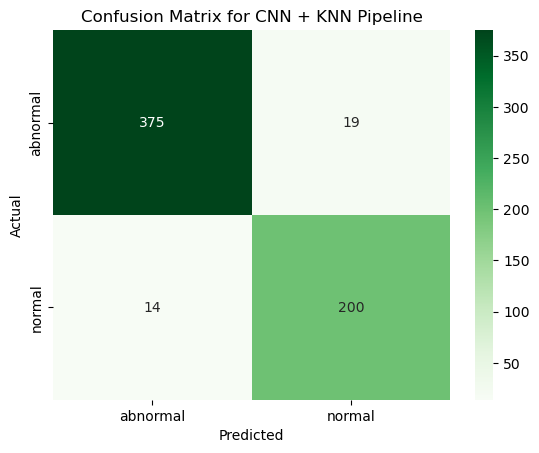

In [29]:
# Confusion Matrix for Test Set (KNN)
cm_knn = confusion_matrix(y_test, test_predictions_knn)
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix for CNN + KNN Pipeline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

This confusion matrix represents the performance of the **CNN + KNN pipeline** in classifying images as either **abnormal** or **normal**. The matrix has the following breakdown:

- **True Positives (375)**: Abnormal cases correctly predicted as abnormal.
- **False Positives (19)**: Normal cases incorrectly predicted as abnormal.
- **True Negatives (200)**: Normal cases correctly predicted as normal.
- **False Negatives (14)**: Abnormal cases incorrectly predicted as normal.

The majority of predictions are correct, as evidenced by the high values along the diagonal (375 and 200). The low off-diagonal values (19 and 14) indicate very few misclassifications. This demonstrates that the model performs well in both sensitivity (correctly identifying abnormal cases) and specificity (correctly identifying normal cases).

### 7. Evaluation

In [30]:
# Summary of Results
print("Model Performance Summary:")
print(f"CNN + SVM Test Accuracy: {cnn_svm_accuracy:.2f}%")
print(f"CNN + KNN Test Accuracy: {cnn_knn_accuracy:.2f}%")

Model Performance Summary:
CNN + SVM Test Accuracy: 91.61%
CNN + KNN Test Accuracy: 94.57%


The **Model Performance Summary** highlights the effectiveness of both pipelines in classifying images into abnormal and normal categories. The **CNN + SVM pipeline** achieved a solid test accuracy of **91.61%**, showcasing its robustness as a classification model. However, the **CNN + KNN pipeline** outperformed it with a higher test accuracy of **94.57%**, suggesting that the KNN classifier, when combined with CNN-extracted features, was better at capturing subtle patterns in the data. This difference might be attributed to KNN's ability to adapt to local data distributions, making it slightly more flexible in handling the feature space derived from the CNN. Both pipelines demonstrate strong performance, but the CNN + KNN approach may be more suitable for this dataset.

### 8. Cancer Prediction With Type

#### 8.1 Prediction With SVM

In [53]:
def cancerPredictionWithType(path):
    # Define all categories and their binary classification
    classes_dir = ["Dyskeratotic", "Koilocytotic", "Metaplastic", "Parabasal", "Superficial-Intermediate"]
    binary_classes = ["Abnormal", "Normal"]  # Binary classification

    # Load the image
    img = image.load_img(path, target_size=(64, 64))  # Resize to match CNN input
    # Normalize the image and convert to numpy array
    norm_img = image.img_to_array(img) / 255.0
    input_arr_img = np.expand_dims(norm_img, axis=0)  # Add batch dimension

    # Extract features using the CNN feature extractor
    extracted_features = feature_extractor.predict(input_arr_img)

    # Apply PCA transformation (trained earlier)
    transformed_features = pca.transform(extracted_features)

    # Make a prediction using the trained SVM
    pred = svm_model.predict(transformed_features)
    predicted_class = int(pred[0])

    # Determine binary category and detailed type
    if predicted_class in [3, 4]:  # Class labels for "Parabasal" and "Superficial-Intermediate"
        print(f"Predicted Class: {binary_classes[1]} ({classes_dir[predicted_class]})")  # Normal
    else:
        print(f"Predicted Class: {binary_classes[0]} ({classes_dir[predicted_class]})")  # Abnormal

# Example Usage
path = "/Users/altalhishahd/Desktop/DS Master Files/Semester 3/Machine Learning/project/archive/im_Dyskeratotic/im_Dyskeratotic/CROPPED/002_02.bmp"
cancerPredictionWithType(path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Predicted Class: Abnormal (Dyskeratotic)


#### 8.1 Prediction With KNN

In [54]:
def cancerPredictionWithKNN(path):
    # Define all categories and their binary classification
    classes_dir = ["Dyskeratotic", "Koilocytotic", "Metaplastic", "Parabasal", "Superficial-Intermediate"]
    binary_classes = ["Abnormal", "Normal"]  # Binary classification

    # Load the image
    img = image.load_img(path, target_size=(64, 64))  # Resize to match CNN input
    # Normalize the image and convert to numpy array
    norm_img = image.img_to_array(img) / 255.0
    input_arr_img = np.expand_dims(norm_img, axis=0)  # Add batch dimension

    # Extract features using the CNN feature extractor
    extracted_features = feature_extractor.predict(input_arr_img)

    # Apply PCA transformation (trained earlier)
    transformed_features = pca.transform(extracted_features)

    # Make a prediction using the trained KNN
    pred = knn_model.predict(transformed_features)
    predicted_class = int(pred[0])

    # Determine binary category and detailed type
    if predicted_class in [3, 4]:  # Class labels for "Parabasal" and "Superficial-Intermediate"
        print(f"Predicted Class: {binary_classes[1]} ({classes_dir[predicted_class]})")  # Normal
    else:
        print(f"Predicted Class: {binary_classes[0]} ({classes_dir[predicted_class]})")  # Abnormal

# Example Usage
path = "/Users/altalhishahd/Desktop/DS Master Files/Semester 3/Machine Learning/project/archive/im_Dyskeratotic/im_Dyskeratotic/CROPPED/002_02.bmp"
cancerPredictionWithKNN(path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Predicted Class: Abnormal (Dyskeratotic)
